In [1]:
# This file is mainly used for doing stream statistics.
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pa3.utils.env import load_dotenv
from pa3.utils.statistics import IQR_bound

load_dotenv()
PA3_REPO_ROOT = Path(os.environ["PA3_REPO_ROOT"]).expanduser()


def pa3_path(relative_path: str) -> str:
    return str(PA3_REPO_ROOT / relative_path)

def stream_numbers_fetch(db: pd.DataFrame, protocol: str, host: str):
    """
    Get the number of streams for the given protocol and host.
    """
    groups = db[(db['protocol'] == protocol) & (db['host'] == host)].groupby('id')
    stream_numbers = []
    for _, group in groups:
        stream_numbers.append(group.shape[0])
    return np.array(stream_numbers)

def select_features_by_host(npz_file, host_name, feature_key='hsdbs'):
    """
    Select features for a specific host from an npz file.
    
    Parameters:
    npz_file: The loaded npz file containing 'hosts', 'labels', and feature data
    host_name (str): The name of the host to select features for
    feature_key (str): The key name for the feature data in the npz file (default: 'hsdbs')
    
    Returns:
    tuple: (selected_features, selected_labels) - Features and labels for the specified host
    """
    hosts = npz_file['hosts']
    labels = npz_file['labels']
    features = npz_file[feature_key]
    
    # Find the index of the host in the hosts array
    host_indices = np.where(hosts == host_name)[0]
    
    if len(host_indices) == 0:
        raise ValueError(f"Host '{host_name}' not found in the dataset")
    
    # Get the label corresponding to this host (should be the same for all instances)
    host_label = labels[host_indices[0]]
    
    # Find all features where the label matches the host's label
    mask = labels == host_label
    selected_features = features[mask]
    selected_labels = labels[mask]
    
    return selected_features, selected_labels

def select_features_by_hosts(npz_file, host_names, feature_key='hsdbs'):
    """
    Select features for multiple hosts from an npz file.
    
    Parameters:
    npz_file: The loaded npz file containing 'hosts', 'labels', and feature data
    host_names (list): List of host names to select features for
    feature_key (str): The key name for the feature data in the npz file (default: 'hsdbs')
    
    Returns:
    tuple: (selected_features, selected_labels) - Features and labels for the specified hosts
    """
    hosts = npz_file['hosts']
    labels = npz_file['labels']
    features = npz_file[feature_key]
    
    # Find the labels corresponding to the requested hosts
    host_labels = []
    if isinstance(host_names, str):
        host_names = [host_names]
    for host_name in host_names:
        host_indices = np.where(hosts == host_name)[0]
        if len(host_indices) == 0:
            raise ValueError(f"Host '{host_name}' not found in the dataset")
        host_labels.append(host_indices.item())
    
    # Find all features where the label matches any of the requested host labels
    mask = (labels == host_labels)
    selected_features = features[mask]
    selected_labels = labels[mask]
    
    return selected_features, selected_labels

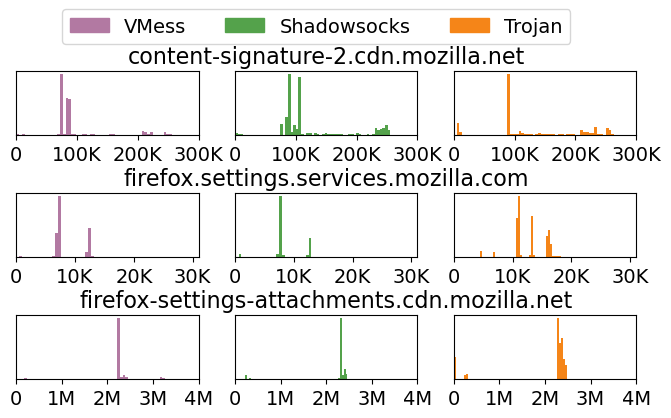

In [ ]:
# Reproduction of Fig. 3 The BIH flow size patterns
import matplotlib.patches as mpatches

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

root_dir = "../data_extract"


dfs = dict()
dfs['content-signature-2.cdn.mozilla.net'] = pd.read_csv(f"{root_dir}/content-signature-2.cdn.mozilla.net.csv")
dfs['firefox.settings.services.mozilla.com'] = pd.read_csv(f"{root_dir}/firefox.settings.services.mozilla.com.csv")
dfs['firefox-settings-attachments.cdn.mozilla.net'] = pd.read_csv(f"{root_dir}/firefox-settings-attachments.cdn.mozilla.net.csv")

# Each csv contains the same columns: trojan, vmess, shadowsocks
# For each csv, for each column, compute the histogram of the column, where the bins are of size 500.
arrays = {'content-signature-2.cdn.mozilla.net': [], 'firefox.settings.services.mozilla.com': [], 'firefox-settings-attachments.cdn.mozilla.net': []}
for sni in dfs:
    columns = []
    for proto in ['vmess', 'shadowsocks', 'trojan']:
        col = dfs[sni][proto].dropna().to_numpy().astype(np.int64)
        n = max(1, int(len(col) * .5))
        if n < len(col):
            col = np.random.choice(col, n, replace=False)
        columns.append(col)
    arrays[sni] = columns

protocols = ["VMess", "Shadowsocks", "Trojan"]
color_map = ["#B279A2", "#54A24B", "#F58518"]

patches = [mpatches.Patch(color=color_map[i], label=protocols[i]) for i in range(3)]

x_lim = [300000, 31_000, 4e6]
x_ticks = [
    [0, 100_000, 200_000, 300_000],     # 0, 100K, 200K, 300K
    [0, 10_000, 20_000, 30_000],     # 0, 10K, 20K, 30K
    [0, 1_000_000, 2_000_000, 3_000_000, 4_000_000]   # 0, 1M, 2M, 3M, 4M
]
x_ticklabels = [
    ['0', '100K', '200K', '300K'],
    ['0', '10K', '20K', '30K'],
    ['0', '1M', '2M', '3M', '4M']
]

fig, axes = plt.subplots(3, 3, figsize=(8, 4))

for j in range(3):
    for i, sni in enumerate(dfs):
        axes[i, j].hist(arrays[sni][j][arrays[sni][j] < x_lim[i]], bins=60, color=color_map[j], label=protocols[j])
        axes[i, j].set_xlim(0, x_lim[i])
        axes[i, j].tick_params(axis='x', labelsize=14)
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks(x_ticks[i])
        axes[i, j].set_xticklabels(x_ticklabels[i])
        axes[i, 1].set_title(sni, fontsize=16)
            

# Manually create a legend for the whole figure
fig.legend(handles=patches, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.06), fontsize=14)

fig.subplots_adjust(hspace=0.9, wspace=0.2)
# plt.savefig('histograms.png')

plt.savefig('browser_noise.pdf', bbox_inches='tight', dpi=300, format='pdf')

In [ ]:
# Reproduction of Fig. 5 Server/Client Hello intra-flow indices
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
from scipy import stats

fig, ax = plt.subplots(1, 2, figsize=(8, 2))
fig.subplots_adjust(wspace=0.25)  # Adjust horizontal distance between subplots

ch_df = pd.read_csv(pa3_path("VisualSeg/ch_search/database.csv"))
sh_df = pd.read_csv(pa3_path("VisualSeg/sh_search/database.csv"))

protocols = ['NoProxy', 'VMess', 'Shadowsocks', 'Trojan']
color_map = {"NoProxy": "#4C78A8", "VMess": "#B279A2", "Shadowsocks": "#54A24B", "Trojan": "#F58518"}

xticks = [0, 5, 10, 15, 20, 25]
xtick_labels = [str(x) for x in xticks]

# --- Client Hello (CH) subplot ---
y_max_ch = 0  # to self-decide y-lim for CH
for protocol in protocols:
    data = ch_df.query(f"{protocol.lower()} >= 0")[protocol.lower()].tolist()
    hist, edges = np.histogram(data, bins=20, range=(0, 20), density=True)
    kde = stats.gaussian_kde(data)
    x_vals = np.linspace(min(edges), max(edges), 500)
    y_vals = kde(x_vals)
    ax[0].plot(x_vals, y_vals, color=color_map[protocol], label=protocol, linewidth=1)
    ax[0].fill_between(x_vals, y_vals, alpha=0.3, color=color_map[protocol])
    y_max_ch = max(y_max_ch, np.max(y_vals))
ax[0].set_xlabel('Packet Index', fontsize=16)
ax[0].set_ylabel('Density', fontsize=16)
ax[0].set_title('Client Hello Index', fontsize=16)
ax[0].tick_params(axis='x', labelsize=14)
ax[0].set_xticks(xticks)
ax[0].set_xticklabels(xtick_labels)
ax[0].tick_params(axis='y', labelsize=14)
# Set 5 y-ticks and y-lim automatically based on data
ax[0].set_ylim(0, np.ceil(y_max_ch * 1.1 * 10) / 10 if y_max_ch > 0 else 1)
ax[0].yaxis.set_major_locator(plt.MaxNLocator(nbins=5))

# --- Server Hello (SH) subplot ---
y_max_sh = 0  # self-decide y-lim for SH
for protocol in protocols:
    data = sh_df.query(f"{protocol.lower()} >= 0")[protocol.lower()].tolist()
    hist, edges = np.histogram(data, bins=25, range=(0, 25), density=True)
    kde = stats.gaussian_kde(data)
    x_vals = np.linspace(min(edges), max(edges), 500)
    y_vals = kde(x_vals)
    ax[1].plot(x_vals, y_vals, color=color_map[protocol], label=protocol, linewidth=1)
    ax[1].fill_between(x_vals, y_vals, alpha=0.3, color=color_map[protocol])
    y_max_sh = max(y_max_sh, np.max(y_vals))
ax[1].set_xlabel('Packet Index', fontsize=16)
ax[1].set_ylabel('Density', fontsize=16)
ax[1].set_title('Server Hello Index', fontsize=16)
ax[1].tick_params(axis='x', labelsize=14)
ax[1].set_xticks(xticks)
ax[1].set_xticklabels(xtick_labels)
ax[1].tick_params(axis='y', labelsize=14)
# Set 5 y-ticks and y-lim automatically based on data
ax[1].set_ylim(0, np.ceil(y_max_sh * 1.1 * 10) / 10 if y_max_sh > 0 else 1)
ax[1].yaxis.set_major_locator(plt.MaxNLocator(nbins=5))

patches = [mpatches.Patch(color=color_map[protocol], label=protocol) for protocol in protocols]
fig.legend(
    handles=patches,
    loc='upper center',
    ncol=4,
    bbox_to_anchor=(0.5, 1.28),
    fontsize=16,
    columnspacing=1  # Increased spacing between labels
)
fig.savefig('packet_index.pdf', bbox_inches='tight', dpi=300, format='pdf')

In [ ]:
# Reproduction of Fig. 6 BFT ranges for different browser versions.

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.ticker import FuncFormatter

def human_format(num, pos=None):
    # Formats number precisely in K, M, G etc. (including "1.5K", "2.7M", etc.)
    if num is None:
        return ""
    num = float(num)
    if num >= 1_000_000_000:
        val = num / 1_000_000_000
        return f'{val:.1f}G' if not val.is_integer() else f'{int(val)}G'
    elif num >= 1_000_000:
        val = num / 1_000_000
        return f'{val:.1f}M' if not val.is_integer() else f'{int(val)}M'
    elif num >= 1:
        val = num / 1_000
        return f'{val:.1f}K' if not val.is_integer() else f'{int(val)}K'
    else:
        return str(int(num)) if num.is_integer() else f"{num:.1f}"

color_map = {"NoProxy": "#4C78A8", "VMess": "#B279A2", "Shadowsocks": "#54A24B", "Trojan": "#F58518"}
protocol_markers = {"NoProxy": "o", "VMess": "s", "Shadowsocks": "^", "Trojan": "D"}

names = [
    [
        "www.office.com_js.monitor.azure.com",  # Short
        "www.cnblogs.com_cdn-www.cnblogs.com", # Short
    ],
    [
        "www.fromgeek.com_www.fromgeek.com",  # Long
        "www.apache.org_www.apache.org",  # Long
    ]
]

index = [
    ['a', 'b'],
    ['c', 'd'],
]

output_root = pa3_path("VisualSeg")
base = "tcp"


fig, axs = plt.subplots(2, 2, figsize=(12, 7))
fig.subplots_adjust(wspace=0.4)

for i, row in enumerate(names):
    for j, name in enumerate(row):
        ax = axs[i][j]
        cv_means = {}
        all_y_values = []  # Collect all Y values for y-lim autoscale

        for protocol in color_map:
            avg_array_path = Path(f"{output_root}/seg_compute/{base}/{protocol.lower()}/avg_{name}.npy")
            std_array_path = Path(f"{output_root}/seg_compute/{base}/{protocol.lower()}/std_{name}.npy")
            avg_byte_segments, std_byte_segments = np.load(avg_array_path), np.load(std_array_path)

            # mid = len(avg_byte_segments) // 2
            mid = 200_000
            if i == 1:
                avg_byte_segments = avg_byte_segments[mid:]
                std_byte_segments = std_byte_segments[mid:]
                x = np.arange(mid, mid + len(avg_byte_segments))
            else:
                x = np.arange(len(avg_byte_segments))

            cv_means[protocol] = float(np.mean(std_byte_segments/avg_byte_segments))
            marker_step = max(1, len(avg_byte_segments) // 10)
            ax.plot(
                x, avg_byte_segments,
                linewidth=2,
                color=color_map[protocol],
                label=f"{protocol}",
                marker=protocol_markers[protocol],
                markevery=marker_step,
                markersize=6,
            )
            all_y_values.extend(avg_byte_segments)  # Collect plotted values for y-lim

        # Remove per-subplot labels; set global labels after the loop
        host, sni = name.split('_')
        # The first row represents host transmitting short flows, the second row represents those transmitting long flows
        ax.set_title(
            f'({index[i][j]}) Host: {sni}' + (f' (Short)' if i == 0 else f' (Long)'),
            fontsize=20,
        )
        # Change xticks font size to 10
        ax.tick_params(axis='x', labelsize=18)
        ax.tick_params(axis='y', labelsize=18)
        # Add human-readable byte tick formatter to x-axis
        ax.xaxis.set_major_formatter(FuncFormatter(human_format))

        # Set y-ticks as instructed
        if i == 0:
            ax.set_yticks([10, 30, 50, 70, 90])
        else:
            ax.set_yticks([400, 600, 800, 1000, 1200])

        max_cv = max(cv_means.values())

        handles, labels = ax.get_legend_handles_labels()

fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.02), fontsize=20)
# Set global labels after the loop
fig.supxlabel('Byte Index', y=0.02, fontsize=20)
fig.supylabel('Intra-flow Segment Index', x=0.04, fontsize=20)
fig.subplots_adjust(hspace=0.3)

fig.savefig('byte_segment_map.pdf', bbox_inches='tight', dpi=300, format='pdf')

In [ ]:
# Reproduction of Fig. 12 BFT ranges for different browser versions.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pa3.utils.statistics import greedy_mass_covering

versions = [v for v in range(132, 142)]
protocols = ["VMess", "Shadowsocks", "Trojan"]
color_map = ["#B279A2", "#54A24B", "#F58518"]
coverage = .4

SNI_BIN_SIZE = {
    'firefox-settings-attachments.cdn.mozilla.net': 20000, 
    'firefox.settings.services.mozilla.com': 500, 
    'content-signature-2.cdn.mozilla.net': 1000
}

fig, axs = plt.subplots(1, 3, figsize=(8, 2), constrained_layout=True, sharey=True)
patches = [mpatches.Patch(color=color_map[i], label=protocols[i]) for i in range(3)]
y_ticks = [0, .5e7, 1e7, 1.5e7]
axs[0].set_xticks(versions)
axs[0].set_ylabel("Size", fontsize=16)
axs[0].set_yticks(y_ticks)
axs[0].tick_params(axis='x', rotation=45, labelsize=14)
axs[0].tick_params(axis='y', labelsize=14)
axs[0].set_title("VMess", fontsize=16)
axs[1].set_xticks(versions)
axs[1].set_yticks(y_ticks)
axs[1].tick_params(axis='x', rotation=45, labelsize=14)
axs[1].set_title("Shadowsocks", fontsize=16)
axs[1].set_xlabel("Firefox Version", fontsize=16)
axs[1].tick_params(axis='y', labelleft=False)
axs[2].set_xticks(versions)
axs[2].set_yticks(y_ticks)
axs[2].tick_params(axis='x', rotation=45, labelsize=14)
axs[2].set_title("Trojan", fontsize=16)
axs[2].tick_params(axis='y', labelleft=False)

for version in versions:
    dfs = dict()
    dfs['content-signature-2.cdn.mozilla.net'] = pd.read_csv(pa3_path(f"VisualSeg/firefox_dataset/{version}/content-signature-2.cdn.mozilla.net.csv"))
    dfs['firefox.settings.services.mozilla.com'] = pd.read_csv(pa3_path(f"VisualSeg/firefox_dataset/{version}/firefox.settings.services.mozilla.com.csv"))
    dfs['firefox-settings-attachments.cdn.mozilla.net'] = pd.read_csv(pa3_path(f"VisualSeg/firefox_dataset/{version}/firefox-settings-attachments.cdn.mozilla.net.csv"))
    for i, protocol in enumerate(protocols):
        total_cover = []
        for sni in dfs:
            array = dfs[sni][protocol.lower()].dropna().to_numpy().astype(np.int64)
            cover, actual_coverage = greedy_mass_covering(array, SNI_BIN_SIZE[sni], coverage)
            total_cover += cover
        
        for cover in total_cover:
            axs[i].scatter(version, (cover[0] + cover[1])/2, color=color_map[i], marker='o')

# fig.legend(handles=patches, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.21), fontsize=14)
plt.savefig('version.pdf', bbox_inches='tight', dpi=300, format='pdf')